# Random Forest (RF) on MHAR Feature Set

**Purpose:** This notebook implements the Random Forest (RF) model of Breiman (2001) on the MHAR feature set for the EURO STOXX 50 index, following the tree-based methodology described in Christensen, Siggaard, and Veliyev (2023). Random Forest extends bagging by forcing each tree split to consider only a random subset of predictors, which helps decorrelate the trees and can improve forecast accuracy when nonlinearities or interaction effects are present. In the reference paper, RF is treated as an off-the-shelf method: the training and validation samples are merged, the forest is re-estimated in a rolling window, and the tree parameters are kept at the default Breiman-Cutler settings rather than tuned in the validation set. We mirror that implementation here so the results remain directly comparable to HAR and the other MHAR model notebooks.

## 1. Imports

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor


## 2. Data Loading

We use the same `MALL.csv` data source as in the HAR, regularized, and benchmark-extension notebooks so that the RF forecasts are evaluated on the exact same sample and information set.

In [2]:
# Load MALL dataset
MALL = pd.read_csv("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv")
MALL["Date"] = pd.to_datetime(MALL["Date"])
MALL = MALL.set_index("Date")

print(f"Sample period: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"Number of observations: {len(MALL)}")
display(MALL[["RVD", "RVW", "RVM", "RV_target"]].head())


Sample period: 1999-01-05 to 2020-08-06
Number of observations: 5489


,RVD,RVW,RVM,RV_target
Date,,,,
1999-01-05,0.000078,0.000093,0.000129,0.000058
1999-01-06,0.000058,0.000092,0.000123,0.000139
1999-01-07,0.000139,0.000102,0.000121,0.000108
1999-01-08,0.000108,0.000106,0.000112,0.000166
1999-01-11,0.000166,0.000110,0.000110,0.000115


## 3. Data Split

We retain the same 70/10/20 split as in the other notebooks. The important difference from the regularized models is that the paper does not use the validation sample to tune RF hyperparameters. Instead, train and validation are merged into the rolling estimation window, yielding an off-the-shelf implementation that is easy to reproduce.

In [3]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(0.70 * n)
n_val = int(0.10 * n)
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")

print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")


Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 4. Feature Set Construction and Standardization

The paper notes that all variables are standardized prior to estimation. While trees are less sensitive to scaling than linear models, we keep the same standardization step for consistency with the reference implementation and with the rest of the thesis pipeline.

In [4]:
# Define target and MHAR feature set
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

# Split into train, validation and test sets
X_train = X_MHAR[:n_train]
X_val = X_MHAR[n_train:n_train + n_val]
X_test = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)

# Scale full dataset using training-set parameters
X_scaled = (X_MHAR - X_mean) / X_std

X_train_scaled = X_scaled[:n_train]
X_val_scaled = X_scaled[n_train:n_train + n_val]
X_test_scaled = X_scaled[n_train + n_val:]

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Means: {X_train_scaled.mean(axis=0).round(6)}")
print(f"  Std:   {X_train_scaled.std(axis=0).round(6)}")


Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  Means: [-0.  0. -0.]
  Std:   [1. 1. 1.]


## 5. Random Forest Specification

Following Appendix A.4 of the paper, we keep RF at the Breiman-Cutler default settings rather than tuning hyperparameters in the validation sample. Concretely, we use `500` trees, a minimum terminal-node size of `5`, and a random feature subset at each split. For the MHAR feature set with three predictors, the paper's feature-split rule implies one predictor is considered at each split.

In [5]:
# Random Forest settings following the paper
n_features = X_scaled.shape[1]
max_features = max(1, n_features // 3)

rf_params = {
    "n_estimators": 500,
    "min_samples_leaf": 5,
    "max_features": max_features,
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": 1
}

print("Random Forest parameters:")
for key, value in rf_params.items():
    print(f"  {key}: {value}")

rf_initial = RandomForestRegressor(**rf_params)
rf_initial.fit(X_scaled[:n_train + n_val], y[:n_train + n_val])
feature_importance = pd.Series(rf_initial.feature_importances_, index=["RVD", "RVW", "RVM"])
display(feature_importance.sort_values(ascending=False).to_frame("Initial feature importance"))


Random Forest parameters:
  n_estimators: 500
  min_samples_leaf: 5
  max_features: 1
  bootstrap: True
  random_state: 42
  n_jobs: -1


,Initial feature importance
RVW,0.381217
RVD,0.368368
RVM,0.250415


## 6. Rolling Window Estimation and Forecasting

Because RF is not tuned in the validation sample, the paper merges the training and validation observations and rolls that combined window through the test period. Each day, we re-estimate the forest on the current window and produce a one-step-ahead forecast of realized variance.

In [6]:
window_size = n_train + n_val

print(f"Rolling window length (train + validation): {window_size}")

forecasts_RF = []
dates_test = []
importance_path = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    model_final = RandomForestRegressor(**rf_params)
    model_final.fit(X_window, y_window)

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = model_final.predict(X_forecast)[0]
    forecast = max(forecast, y_window.min())

    forecasts_RF.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    importance_path.append(model_final.feature_importances_)

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_RF)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")
avg_importance = pd.Series(np.mean(np.vstack(importance_path), axis=0), index=["RVD", "RVW", "RVM"])
print("\nAverage feature importance across rolling windows:")
display(avg_importance.sort_values(ascending=False).to_frame("Average importance"))


Rolling window length (train + validation): 4390


  Day  100/1099 | Date: 2016-09-08 | Elapsed: 0.8 min


  Day  200/1099 | Date: 2017-01-27 | Elapsed: 1.6 min


  Day  300/1099 | Date: 2017-06-21 | Elapsed: 2.4 min


  Day  400/1099 | Date: 2017-11-08 | Elapsed: 3.2 min


...

  Day  800/1099 | Date: 2019-06-06 | Elapsed: 7.1 min


  Day  900/1099 | Date: 2019-10-24 | Elapsed: 8.0 min


  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 9.1 min



Total estimation time: 10.1 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06

Average feature importance across rolling windows:


,Average importance
RVW,0.380120
RVD,0.366249
RVM,0.253631


## 7. Save Forecasts

We save the forecast path and the level-scale accuracy measures in the same location and format as the other MHAR notebooks so that later comparison notebooks can load RF without any extra processing.

In [7]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

test_dates = MALL.index[n_train + n_val:]
results_RF = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast": forecasts_RF
}, index=test_dates)

errors_RF = results_RF["RV_actual"] - results_RF["RV_forecast"]
mse_RF = np.mean(errors_RF ** 2)

results_RF.to_csv(os.path.join(forecast_path, "forecasts_RF.csv"))

mse_summary_RF = pd.DataFrame({
    "Model": ["RF"],
    "MSE": [mse_RF],
    "RMSE": [np.sqrt(mse_RF)],
    "MAE": [errors_RF.abs().mean()],
    "Mean_Error": [errors_RF.mean()],
}).set_index("Model")

mse_summary_RF.to_csv(os.path.join(forecast_path, "mse_summary_RF.csv"))

print(f"Forecasts saved to: {forecast_path}")
print(f"Rows saved: {len(results_RF)}")
print(f"Random Forest test-set MSE: {mse_RF:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Rows saved: 1099
Random Forest test-set MSE: 2.199126e-08


## 8. Out-of-Sample Performance Evaluation

We compare RF with the HAR benchmark on the same test period. This mirrors the benchmark-model notebooks and lets us see whether the nonlinear tree-based structure adds value relative to the linear HAR dynamics in this dataset.

In [8]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
results_HAR = pd.read_csv(
    os.path.join(forecast_path, "forecasts_HAR.csv"),
    index_col=0,
    parse_dates=True
)

mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"]) ** 2)
errors_HAR = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
rel_mse_RF = mse_RF / mse_HAR

print(f"Out-of-sample performance ({test_dates[0].date()} to {test_dates[-1].date()}):")
print(f"\n{'Model':<10} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'Mean Error':>12} {'Rel. MSE':>10}")
print("-" * 70)
print(f"{'HAR':<10} {mse_HAR:>12.6e} {np.sqrt(mse_HAR):>12.6e} {errors_HAR.abs().mean():>12.6e} {errors_HAR.mean():>12.6e} {1.0:>10.4f}")
print(f"{'RF':<10} {mse_RF:>12.6e} {np.sqrt(mse_RF):>12.6e} {errors_RF.abs().mean():>12.6e} {errors_RF.mean():>12.6e} {rel_mse_RF:>10.4f}")
print("-" * 70)
print(f"\nRF vs HAR: {'outperforms' if rel_mse_RF < 1 else 'underperforms'} by {abs(1 - rel_mse_RF) * 100:.2f}%")


Out-of-sample performance (2016-04-21 to 2020-08-06):

Model               MSE         RMSE          MAE   Mean Error   Rel. MSE
----------------------------------------------------------------------
HAR        2.221336e-08 1.490415e-04 5.592501e-05 -4.057863e-06     1.0000
RF         2.199126e-08 1.482945e-04 5.425052e-05 -1.314953e-06     0.9900
----------------------------------------------------------------------

RF vs HAR: outperforms by 1.00%


## 9. Forecast Visualization

As in the other notebooks, we convert realized variance into annualized volatility before plotting. This makes the magnitude of the forecasts easier to interpret and keeps the visualization directly comparable across models.

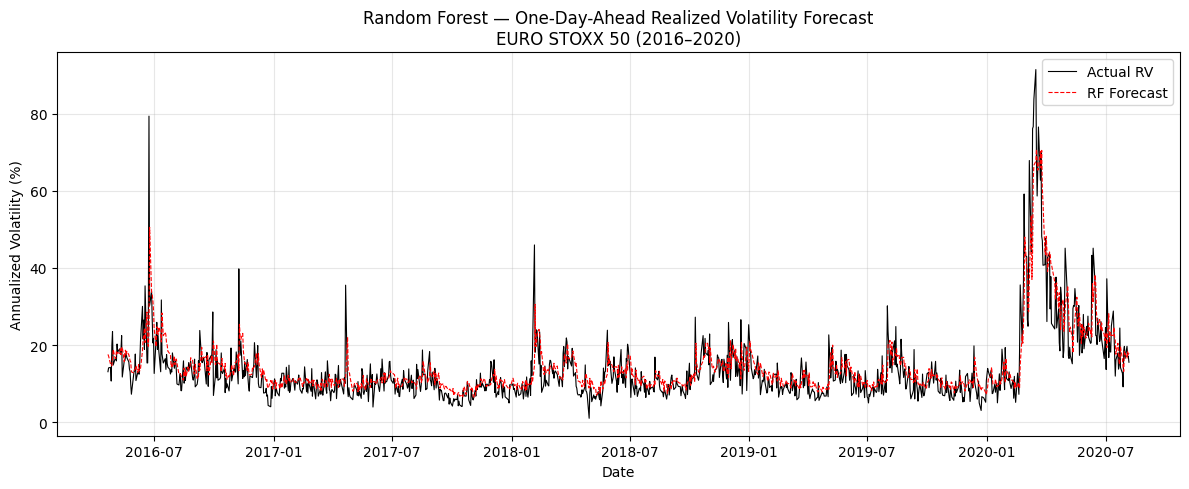


Summary of forecast errors:
Mean error:  -1.314953e-06
RMSE:        1.482945e-04
MAE:         5.425052e-05


In [9]:
results_plot_RF = pd.DataFrame({
    "Actual": np.sqrt(results_RF["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_RF["RV_forecast"] * 252) * 100
}, index=results_RF.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_RF["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot_RF["Forecast"], label="RF Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Random Forest — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
print(f"Mean error:  {errors_RF.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_RF):.6e}")
print(f"MAE:         {errors_RF.abs().mean():.6e}")
